# VNG Stock Price Prediction
### Features: Open, Close, Low, High + Higher High (HH) + A/D Indicator + EMA-9
Three technical indicators are computed on the raw DataFrame **before** windowing,
then appended as additional input features to every sample window.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [2]:
# Load data
df = pd.read_csv('VNG-VNINDEX-History.csv')
df.head()


,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,15574.0,15574.0,15574.0,15574.0,590,2009-12-17
1,1,14795.0,14795.0,14795.0,14795.0,2460,2009-12-18
2,2,14114.0,14114.0,14114.0,14114.0,23290,2009-12-21
3,3,13432.0,13432.0,13432.0,13432.0,57680,2009-12-22
4,4,12848.0,14016.0,12848.0,14016.0,256210,2009-12-23


## Feature Engineering
Compute **Higher High (HH)**, **Accumulation/Distribution (A/D)**, and **EMA-9**
on the full DataFrame before windowing. These columns will be extracted
alongside Open/Close/Low/High inside the sliding window loop.


In [ ]:
#Higher High (10-bar lookback)
#True (1.0) when current bar's high > max of the previous 10 bars' highs.
#shift(1) ensures we exclude the current bar from the lookback window.
rolling_max_high = df['High'].shift(1).rolling(window=10).max()
df['HH'] = (df['High'] > rolling_max_high).astype(float)  # 0.0 or 1.0


# 2. Lower Low (10-bar lookback)
# Mirror of HH — True when price breaks below recent 10-bar support
# Signals sellers are in control and distribution is likely occurring
rolling_min_low   = df['Low'].shift(1).rolling(window=10).min()
df['LL']          = (df['Low'] < rolling_min_low).astype(float)


#Accumulation / Distribution (A/D)
# Money Flow Multiplier = ((Close-Low) - (High-Close)) / (High-Low)
# Money Flow Volume     = MFM * Volume
# A/D line              = cumulative sum of MFV
hl_range   = df['High'] - df['Low']  #Compute daily price rangge
hl_range   = hl_range.replace(0, np.nan)     # avoid divide-by-zero when high=low
mfm        = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / hl_range
#Compute Money Flow Multiplier
mfm        = mfm.fillna(0)
df['AD']   = (mfm * df['Volume']).cumsum()


#Normalise the A/D line to a 0-1 range so it has the same scale as prices.
# We use a rolling min/max over the same 30-day window as our feature window.
ad_min     = df['AD'].rolling(30).min()     #Look back over 30 days and find min A/D value
ad_max     = df['AD'].rolling(30).max()
ad_range   = (ad_max - ad_min).replace(0, np.nan)   #Avoid divide zero
df['AD_norm'] = ((df['AD'] - ad_min) / ad_range).fillna(0)
# A/D slope over 20 bars: positive = net buying (accumulation), negative = net selling (distribution)
df['AD_slope'] = df['AD'].diff(20)

#Add volume data
vol_ratio = df['Volume'] / df['Volume'].rolling(20).mean()


#EMA-9
# Exponential Moving Average over 9 bars.
# We also normalise: value of 1.0 means price == EMA (no gap), >1 = above EMA.
df['EMA9'] = df['Close'].ewm(span=9, adjust=False).mean()
df['EMA9_ratio'] = df['Close'] / df['EMA9']   # ratio keeps it scale-free

# Drop the first 9 rows where EMA / rolling lookbacks are not yet valid
df = df.iloc[9:].reset_index(drop=True)
vol_ratio = vol_ratio.iloc[9:].reset_index(drop=True)


print(f"DataFrame shape after feature engineering: {df.shape}")
print("New columns:", ['HH', 'AD_norm', 'EMA9_ratio', 'LL'])
df[['Open', 'High', 'Low', 'Close', 'HH', 'AD_norm', 'EMA9_ratio', 'LL', 'Volume']].head(5)


DataFrame shape after feature engineering: (3265, 20)
New columns: ['HH', 'AD_norm', 'EMA9_ratio', 'LL']


,Open,High,Low,Close,HH,AD_norm,EMA9_ratio,LL,Volume
0,10415.0,10610.0,10415.0,10610.0,0.0,0.0,0.958293,0.0,22300
1,10707.0,10707.0,10123.0,10123.0,0.0,0.0,0.930251,0.0,23050
2,10318.0,10318.0,9636.0,9636.0,0.0,0.0,0.906251,1.0,34050
3,9734.0,9734.0,9344.0,9344.0,0.0,0.0,0.900622,1.0,12780
4,9344.0,9734.0,9344.0,9539.0,0.0,0.0,0.934478,0.0,25880


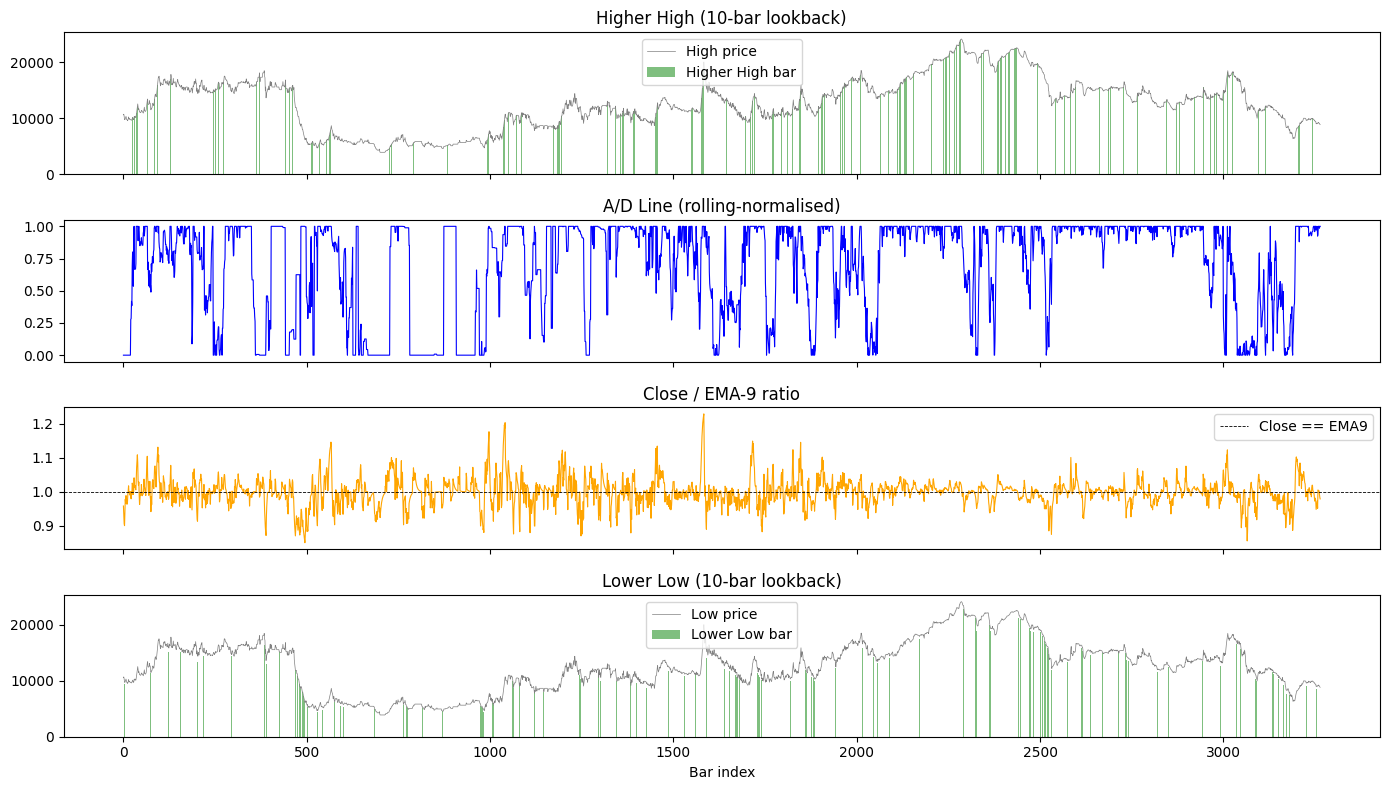

In [12]:
# Quick sanity-check plot of the three new features
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

axes[0].bar(df.index[df['HH'] == 1.0], df.loc[df['HH'] == 1.0, 'High'],
            color='green', alpha=0.5, label='Higher High bar')
axes[0].plot(df['High'], color='gray', linewidth=0.5, label='High price')
axes[0].set_title('Higher High (10-bar lookback)'); axes[0].legend()

axes[1].plot(df['AD_norm'], color='blue', linewidth=0.8)
axes[1].set_title('A/D Line (rolling-normalised)')

axes[2].plot(df['EMA9_ratio'], color='orange', linewidth=0.8)
axes[2].axhline(1.0, color='black', linestyle='--', linewidth=0.6, label='Close == EMA9')
axes[2].set_title('Close / EMA-9 ratio'); axes[2].legend()

axes[3].bar(df.index[df['LL'] == 1.0], df.loc[df['LL'] == 1.0, 'Low'],
            color='green', alpha=0.5, label='Lower Low bar')
axes[3].plot(df['High'], color='gray', linewidth=0.5, label='Low price')
axes[3].set_title('Lower Low (10-bar lookback)'); axes[3].legend()

plt.xlabel('Bar index'); plt.tight_layout(); plt.show()


## Accumulation zone overlay
Visualise **which test bars had all three accumulation signals active**
at the same time: Higher High + rising A/D + price above EMA-20.


In [13]:
# ── Accumulation zone: all three bullish signals fire together ────────────
df['accum_zone'] = (
    (df['HH']          == 1.0) &   # Higher High: buyers breaking resistance
    (df['AD_slope']     > 0)   &   # A/D rising: net volume = buying
    (df['EMA9_ratio']  > 1.0)     # Price above EMA-20: uptrend intact
).astype(int)

# ── Distribution zone: all four bearish signals fire together ────────────
df['dist_zone'] = (
    (df['LL']          == 1.0) &   # Lower Low: sellers breaking support
    (df['AD_slope']     < 0)   &   # A/D falling: net volume = selling
    (df['EMA9_ratio']  < 1.0)  &
    (vol_ratio > 1.1)
).astype(int)

accum_count = df['accum_zone'].sum()
dist_count  = df['dist_zone'].sum()
total       = len(df)

print(f'Total bars         : {total}')
print(f'Accumulation bars  : {accum_count}  ({100*accum_count/total:.1f}%)')
print(f'Distribution bars  : {dist_count}   ({100*dist_count/total:.1f}%)')
print(f'Neutral bars       : {total - accum_count - dist_count}')

Total bars         : 3265
Accumulation bars  : 387  (11.9%)
Distribution bars  : 59   (1.8%)
Neutral bars       : 2819


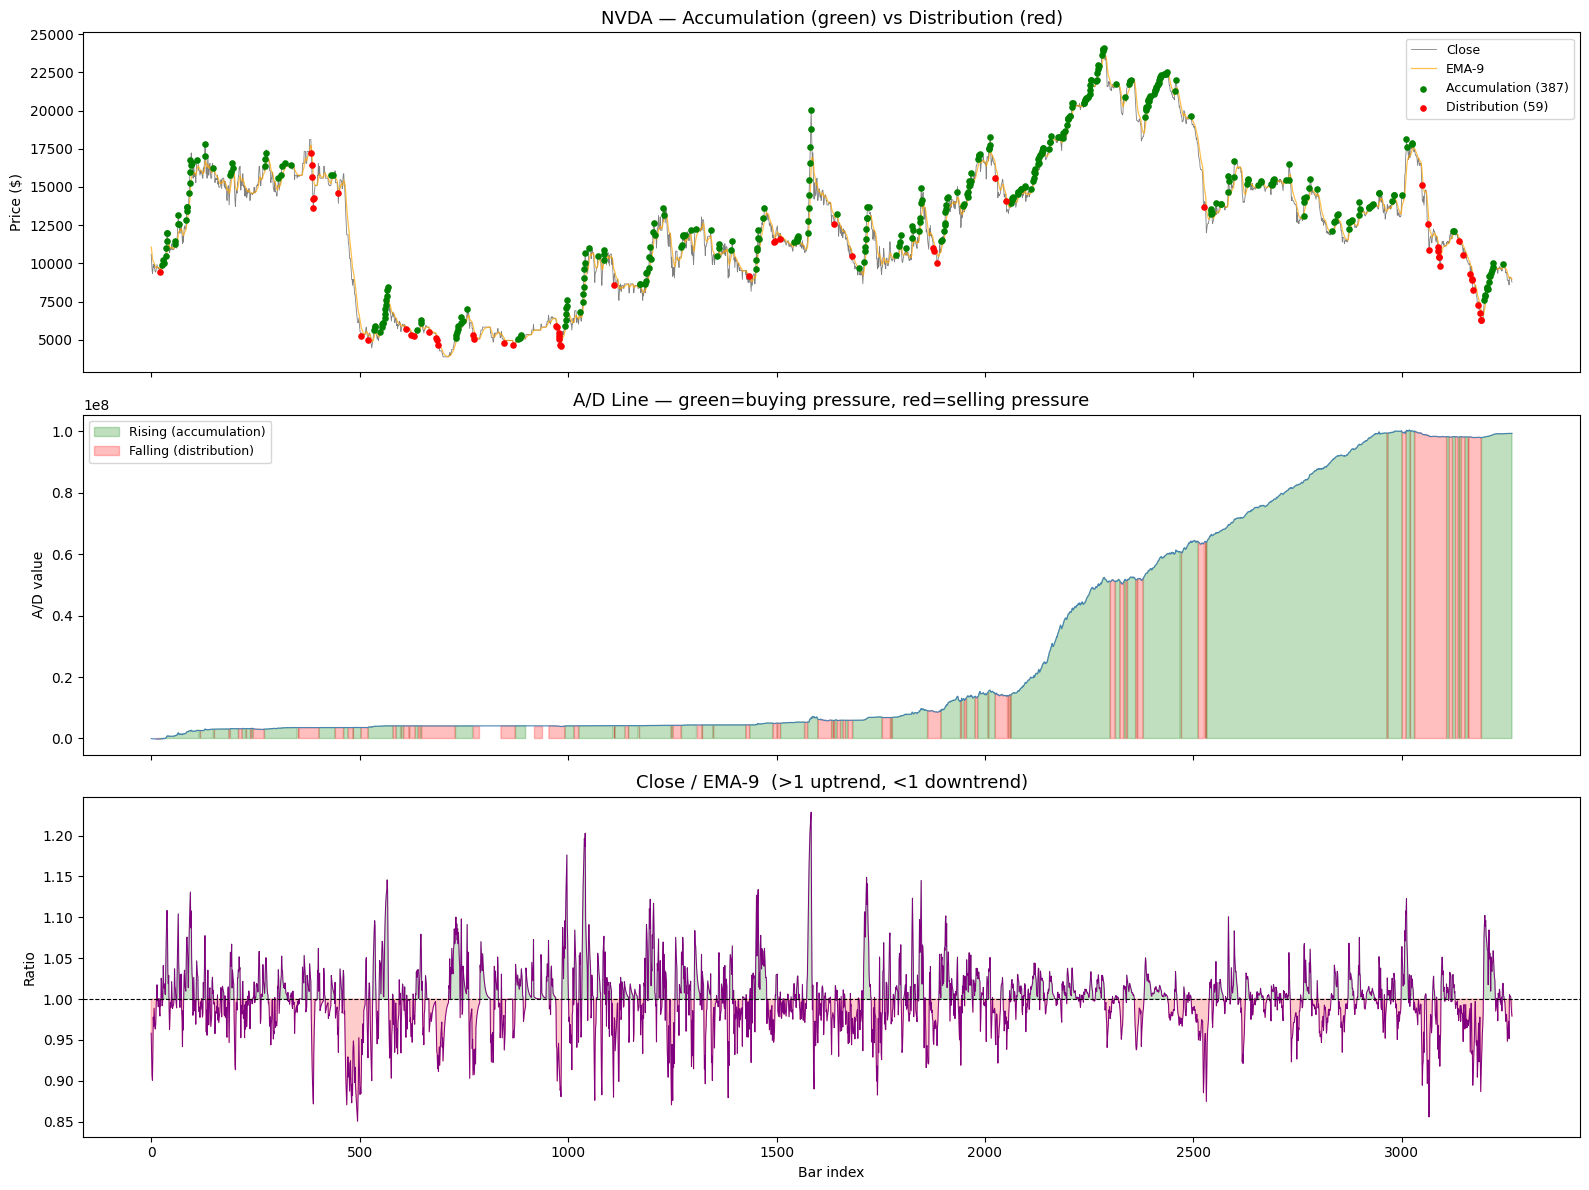

In [14]:
# ── Plot: price chart with both zones highlighted ─────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Panel 1: Price + zones + EMA
axes[0].plot(df['Close'], color='gray', linewidth=0.6, label='Close')
axes[0].plot(df['EMA9'], color='orange', linewidth=0.9, alpha=0.7, label='EMA-9')
axes[0].scatter(
    df.index[df['accum_zone']==1], df.loc[df['accum_zone']==1,'Close'],
    color='green', s=14, zorder=5, label=f'Accumulation ({accum_count})')
axes[0].scatter(
    df.index[df['dist_zone']==1], df.loc[df['dist_zone']==1,'Close'],
    color='red', s=14, zorder=5, label=f'Distribution ({dist_count})')
axes[0].set_title('NVDA — Accumulation (green) vs Distribution (red)', fontsize=13)
axes[0].set_ylabel('Price ($)'); axes[0].legend(fontsize=9)

# Panel 2: A/D line shaded by direction
axes[1].plot(df['AD'], color='steelblue', linewidth=0.8)
axes[1].fill_between(df.index, df['AD'], where=df['AD_slope']>0, alpha=0.25, color='green', label='Rising (accumulation)')
axes[1].fill_between(df.index, df['AD'], where=df['AD_slope']<0, alpha=0.25, color='red',   label='Falling (distribution)')
axes[1].set_title('A/D Line — green=buying pressure, red=selling pressure', fontsize=13)
axes[1].set_ylabel('A/D value'); axes[1].legend(fontsize=9)

# Panel 3: EMA ratio
axes[2].plot(df['EMA9_ratio'], color='purple', linewidth=0.7)
axes[2].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[2].fill_between(df.index, df['EMA9_ratio'], 1.0, where=df['EMA9_ratio']>=1.0, alpha=0.2, color='green')
axes[2].fill_between(df.index, df['EMA9_ratio'], 1.0, where=df['EMA9_ratio']< 1.0, alpha=0.2, color='red')
axes[2].set_title('Close / EMA-9  (>1 uptrend, <1 downtrend)', fontsize=13)
axes[2].set_ylabel('Ratio'); axes[2].set_xlabel('Bar index')

plt.tight_layout(); plt.show()

## Backtesting the Combined Signal — Hit Rate Analysis

**Hit rate** = fraction of signal bars where price was *higher* N days later.  
e.g. signal fired 862 times → price rose after 5 days in 468 cases → **54.4% hit rate**.

We test four forward horizons (1 / 3 / 5 / 10 days) and also measure:
- **Average return** on signal bars vs. all bars (edge check)  
- **Win / loss ratio** and **profit factor**  


In [15]:
HORIZONS = [10, 20, 30, 40] #Medium-term prediction

# Forward return for each horizon: (future price / current price) - 1
for h in HORIZONS:
    df[f'fwd_ret_{h}d'] = df['Close'].shift(-h) / df['Close'] - 1

# Isolate signal bars; drop last 40 rows
sig_accum = df[df['accum_zone'] == 1].iloc[:-40].copy()
sig_dist  = df[df['dist_zone']  == 1].iloc[:-40].copy()
all_bars  = df.iloc[:-40].copy()

results_accum = {}
results_dist  = {}

for h in HORIZONS:
    col = f'fwd_ret_{h}d'
    baseline = all_bars[col].dropna().mean()

    # Accumulation: win = price went UP
    a = sig_accum[col].dropna()
    results_accum[h] = dict(
        hit  = (a > 0).mean(),
        avg  = a.mean(),
        edge = a.mean() - baseline,
        pf   = a[a>0].sum() / a[a<0].abs().sum() if a[a<0].abs().sum() > 0 else float('inf'),
        rets = a
    )

    # Distribution: win = price went DOWN
    d = sig_dist[col].dropna()
    results_dist[h] = dict(
        hit  = (d < 0).mean(),
        avg  = d.mean(),
        edge = baseline - d.mean(),     # positive if dist avg return is below baseline
        pf   = d[d<0].abs().sum() / d[d>0].sum() if d[d>0].sum() > 0 else float('inf'),
        rets = d
    )

print('ACCUMULATION ZONE  (hit = price rose after signal)')
print(f'{"Horizon":<10} {"Hit Rate":>10} {"Avg Ret":>10} {"Edge":>8} {"Profit Factor":>14}')
print('-'*56)
for h in HORIZONS:
    r = results_accum[h]
    print(f'{str(h)+"d":<10} {r["hit"]*100:>9.1f}% {r["avg"]*100:>9.2f}% {r["edge"]*100:>7.2f}% {r["pf"]:>14.2f}x')

print()
print('DISTRIBUTION ZONE  (hit = price fell after signal)')
print(f'{"Horizon":<10} {"Hit Rate":>10} {"Avg Ret":>10} {"Edge":>8} {"Profit Factor":>14}')
print('-'*56)
for h in HORIZONS:
    r = results_dist[h]
    print(f'{str(h)+"d":<10} {r["hit"]*100:>9.1f}% {r["avg"]*100:>9.2f}% {r["edge"]*100:>7.2f}% {r["pf"]:>14.2f}x')

ACCUMULATION ZONE  (hit = price rose after signal)
Horizon      Hit Rate    Avg Ret     Edge  Profit Factor
--------------------------------------------------------
10d             51.3%      1.30%    0.85%           1.48x
20d             57.3%      1.67%    0.71%           1.48x
30d             58.2%      2.42%    0.99%           1.58x
40d             53.3%      1.47%   -0.34%           1.29x

DISTRIBUTION ZONE  (hit = price fell after signal)
Horizon      Hit Rate    Avg Ret     Edge  Profit Factor
--------------------------------------------------------
10d             52.6%     -1.33%    1.78%           1.46x
20d             47.4%     -0.33%    1.30%           1.06x
30d             42.1%     -0.69%    2.12%           1.13x
40d             47.4%     -0.92%    2.73%           1.17x


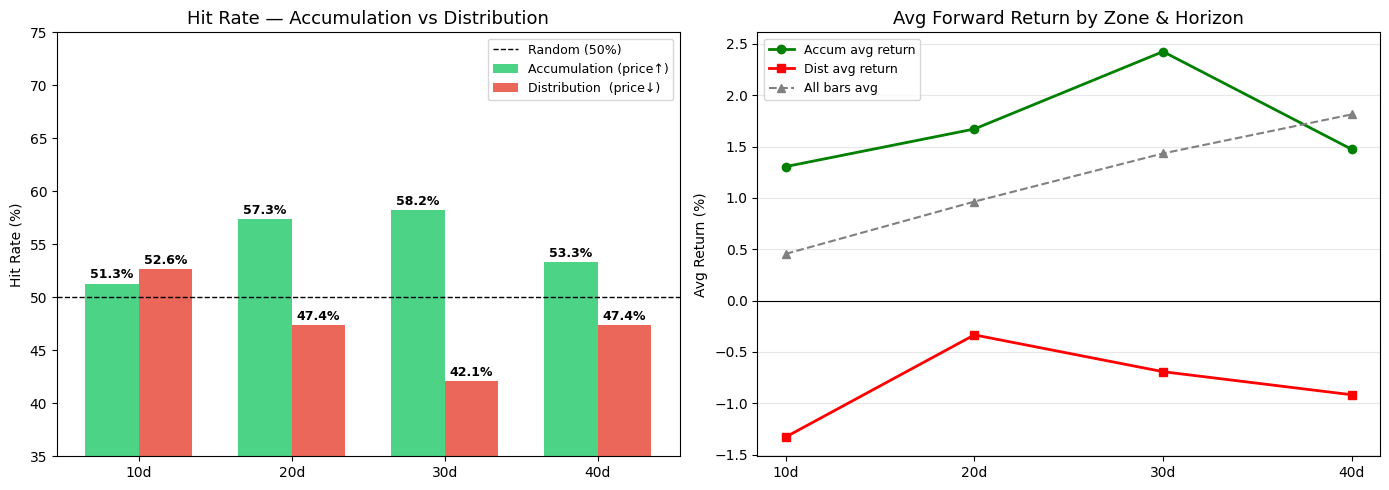

In [16]:
# ── Hit rate bar chart: accumulation vs distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [f'{h}d' for h in HORIZONS]
x = np.arange(len(HORIZONS)); w = 0.35

a_hits = [results_accum[h]['hit']*100 for h in HORIZONS]
d_hits = [results_dist[h]['hit']*100  for h in HORIZONS]

axes[0].bar(x-w/2, a_hits, w, label='Accumulation (price↑)', color='#2ecc71', alpha=0.85)
axes[0].bar(x+w/2, d_hits, w, label='Distribution  (price↓)', color='#e74c3c', alpha=0.85)
axes[0].axhline(50, color='black', linestyle='--', linewidth=1, label='Random (50%)')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title('Hit Rate — Accumulation vs Distribution', fontsize=13)
axes[0].set_ylabel('Hit Rate (%)'); axes[0].set_ylim(35, 75); axes[0].legend(fontsize=9)
for i,(a,d) in enumerate(zip(a_hits,d_hits)):
    axes[0].text(i-w/2, a+0.5, f'{a:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i+w/2, d+0.5, f'{d:.1f}%', ha='center', fontsize=9, fontweight='bold')

a_avgs   = [results_accum[h]['avg']*100 for h in HORIZONS]
d_avgs   = [results_dist[h]['avg']*100  for h in HORIZONS]
all_avgs = [all_bars[f'fwd_ret_{h}d'].mean()*100 for h in HORIZONS]

axes[1].plot(labels, a_avgs,   'o-', color='green', linewidth=2,   label='Accum avg return')
axes[1].plot(labels, d_avgs,   's-', color='red',   linewidth=2,   label='Dist avg return')
axes[1].plot(labels, all_avgs, '^--',color='gray',  linewidth=1.5, label='All bars avg')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Forward Return by Zone & Horizon', fontsize=13)
axes[1].set_ylabel('Avg Return (%)'); axes[1].legend(fontsize=9); axes[1].grid(axis='y',alpha=0.3)

plt.tight_layout(); plt.show()

In [19]:
# ── Final summary table ───────────────────────────────────────────────────
print('='*62)
print('      VNG — ACCUMULATION vs DISTRIBUTION BACKTEST SUMMARY')
print('='*62)
print(f'  Dataset  : {df["TradingDate"].iloc[0]} → {df["TradingDate"].iloc[-1]}')
print(f'  Total bars             : {len(df)}')
print(f'  Accumulation signals   : {df["accum_zone"].sum()}')
print(f'  Distribution signals   : {df["dist_zone"].sum()}')
print()
print(f'  {"":8} {"── ACCUMULATION ──":>22}   {"── DISTRIBUTION ──":>22}')
print(f'  {"Horizon":<8} {"Hit Rate":>10} {"Avg Ret":>10}   {"Hit Rate":>10} {"Avg Ret":>10}')
print(f'  {"-"*60}')
for h in HORIZONS:
    ra = results_accum[h]; rd = results_dist[h]
    print(f'  {str(h)+"d":<8}'
          f' {ra["hit"]*100:>9.1f}% {ra["avg"]*100:>9.2f}%'
          f'   {rd["hit"]*100:>9.1f}% {rd["avg"]*100:>9.2f}%')
print()
print('  Accumulation hit rate = % signals where price ROSE after N days')
print('  Distribution hit rate = % signals where price FELL after N days')
print('='*62)

      VNG — ACCUMULATION vs DISTRIBUTION BACKTEST SUMMARY
  Dataset  : 2010-01-26 → 2023-02-28
  Total bars             : 3265
  Accumulation signals   : 387
  Distribution signals   : 59

               ── ACCUMULATION ──       ── DISTRIBUTION ──
  Horizon    Hit Rate    Avg Ret     Hit Rate    Avg Ret
  ------------------------------------------------------------
  10d           51.3%      1.30%        52.6%     -1.33%
  20d           57.3%      1.67%        47.4%     -0.33%
  30d           58.2%      2.42%        42.1%     -0.69%
  40d           53.3%      1.47%        47.4%     -0.92%

  Accumulation hit rate = % signals where price ROSE after N days
  Distribution hit rate = % signals where price FELL after N days
